# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Отчет по практическому заданию курса «Машинное обучение»

### 1) Введение. Краткое описание целей и задач работы

- **Цель работы:** изучение теоретических основ линейной регрессии, построение и исследование моделей множественной линейной регрессии, гребневой регрессии (Ridge) и регрессии лассо (Lasso), проведение обучения моделей на реальных данных и сравнительная оценка их качества до и после устранения мультиколлинеарности методом главных компонент (PCA).
- **Постановка задачи:**
  1. Загрузить набор данных Medical Cost Personal Dataset о медицинских расходах пациентов.
  2. Провести первичный разведочный анализ, визуализировать распределения признаков и целевой переменной.
  3. Выполнить предобработку: проверить пропуски и закодировать категориальные признаки.
  4. Построить матрицу корреляций и оценить мультиколлинеарность с помощью фактора инфляции дисперсии (VIF).
  5. Обучить линейную, гребневую и лассо-регрессию с 5-фолдовой кросс-валидацией и оценить RMSE, R² и MAPE.
  6. Устранить мультиколлинеарность методом главных компонент: построить график каменистой осыпи, выбрать число компонент и разобрать факторные нагрузки.
  7. Повторить обучение на главных компонентах и сопоставить метрики с моделями на исходных признаках.
- **Датасет:** Medical Cost Personal Dataset (`insurance.csv`). Наблюдение — один застрахованный пациент. Целевая переменная — годовые медицинские расходы (`charges`).


In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
DATA_PATH = DATA_DIR / "insurance.csv"
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5
VARIANCE_THRESHOLD = 0.95

FEATURES = [
    "age",
    "bmi",
    "children",
    "sex_male",
    "smoker_yes",
    "region_northwest",
    "region_southeast",
    "region_southwest",
]
TARGET = "charges"

LABELS = {
    "charges": "Медицинские расходы",
    "age": "Возраст",
    "bmi": "Индекс массы тела",
    "children": "Количество детей",
    "sex_male": "Пол: мужчина",
    "smoker_yes": "Курит",
    "region_northwest": "Регион: northwest",
    "region_southeast": "Регион: southeast",
    "region_southwest": "Регион: southwest",
}
MODEL_TITLES = {"linear": "Линейная", "ridge": "Гребневая", "lasso": "Лассо"}
FEATURE_SET_TITLES = {"original": "Исходные признаки", "pca": "Главные компоненты"}

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
if not DATA_PATH.exists() or DATA_PATH.stat().st_size == 0:
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

raw = pd.read_csv(DATA_PATH)
display(raw.isna().sum().to_frame("пропуски"))
display(raw.head())


,пропуски
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Пояснение к загрузке данных

- **Объем выборки:** исходная таблица содержит **1338 пациентов** и **7 столбцов**.
- **Полнота данных:** пропущенных значений нет. Импутация и удаление строк не требуются.
- **Структура признаков:** числовые характеристики — возраст (`age`), индекс массы тела (`bmi`) и число детей на иждивении (`children`). Категориальные признаки — пол (`sex`), курение (`smoker`) и регион страхования (`region`: northeast, northwest, southeast, southwest).
- **Целевая переменная:** `charges` непрерывна, поэтому далее строится линейная регрессия, а не логистическая.


In [3]:
data = raw.dropna().reset_index(drop=True)
data = pd.get_dummies(data, columns=["sex", "smoker", "region"], drop_first=True, dtype=float)

stats = data[FEATURES + [TARGET]].describe().T
stats.to_csv(OUTPUT_DIR / "describe.csv", encoding="utf-8-sig")
display(stats.round(2))


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.0,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.0,1.09,1.21,0.00,0.00,1.00,2.00,5.00
sex_male,1338.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
smoker_yes,1338.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00
region_northwest,1338.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
region_southeast,1338.0,0.27,0.45,0.00,0.00,0.00,1.00,1.00
region_southwest,1338.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
charges,1338.0,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


### Пояснение к предобработке данных

- **Пропуски:** удалять строки не пришлось. Рабочая выборка — **1338 наблюдений**.
- **Кодирование категорий:** пол, курение и регион переведены в индикаторы с удалением первой категории. Базовые уровни — женщина, некурящий пациент и регион northeast. Так не возникает ловушки фиктивных переменных: сумма дамми-столбцов одной категории вместе со свободным членом не равна константе.
- **Масштаб признаков:** средние расходы равны **13 270,42** (от 1 121,87 до 63 770,43). Возраст измеряется годами (среднее 39,2), BMI — единицами индекса (среднее 30,66), число детей — небольшими целыми (среднее 1,09). Курящих пациентов около 20,5%. Из-за разного масштаба перед Ridge, Lasso и PCA нужна стандартизация
$$z = \frac{x - \mu}{\sigma},$$
где $\mu$ и $\sigma$ считаются только по обучающей части.


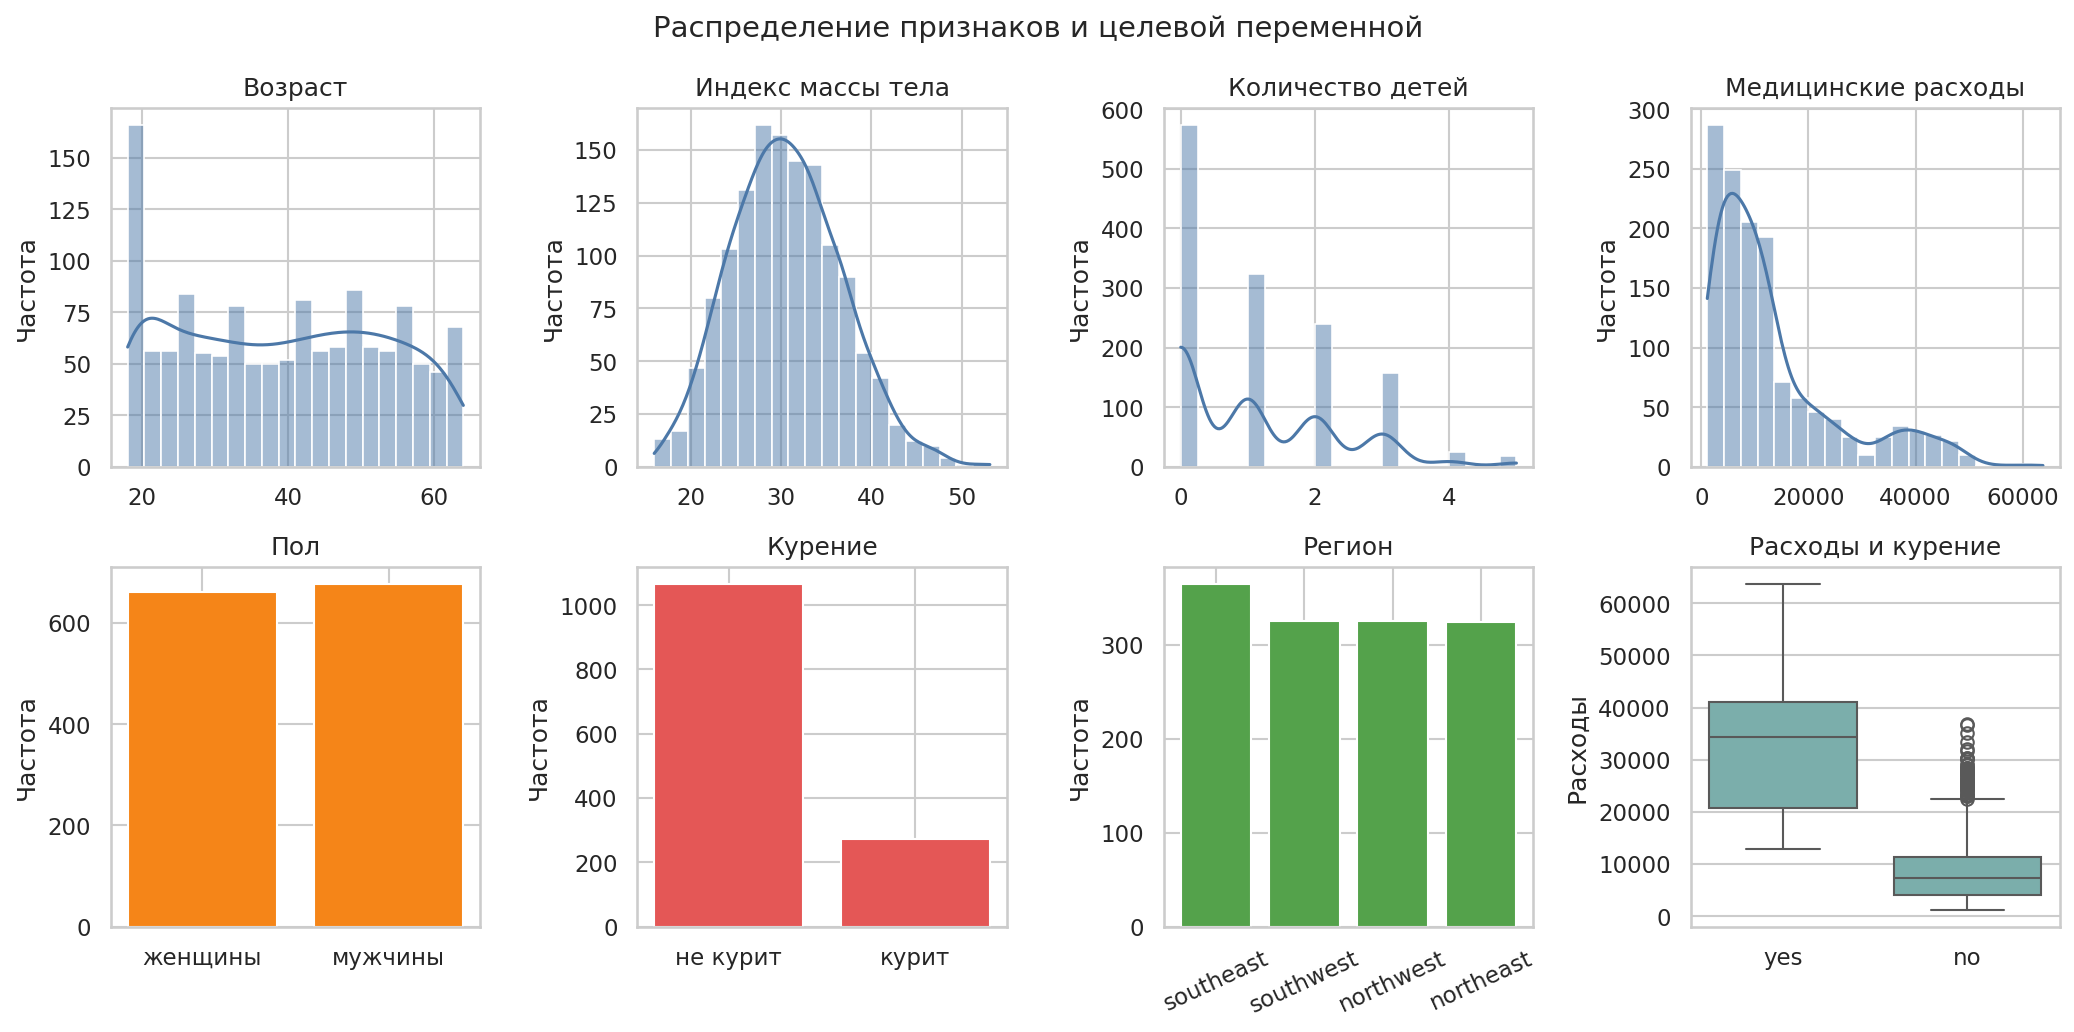

In [4]:
continuous = ["age", "bmi", "children", "charges"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, continuous):
    sns.histplot(data[column], bins=20, kde=True, ax=ax, color="#4C78A8")
    ax.set_title(LABELS[column])
    ax.set_xlabel("")
    ax.set_ylabel("Частота")

sex = raw["sex"].value_counts().reindex(["female", "male"])
axes[4].bar(["женщины", "мужчины"], sex.values, color="#F58518")
axes[4].set_title("Пол")
axes[4].set_ylabel("Частота")

smoker = raw["smoker"].value_counts().reindex(["no", "yes"])
axes[5].bar(["не курит", "курит"], smoker.values, color="#E45756")
axes[5].set_title("Курение")
axes[5].set_ylabel("Частота")

region = raw["region"].value_counts()
axes[6].bar(region.index, region.values, color="#54A24B")
axes[6].set_title("Регион")
axes[6].tick_params(axis="x", rotation=25)
axes[6].set_ylabel("Частота")

sns.boxplot(data=raw, x="smoker", y="charges", ax=axes[7], color="#72B7B2")
axes[7].set_title("Расходы и курение")
axes[7].set_xlabel("")
axes[7].set_ylabel("Расходы")

fig.suptitle("Распределение признаков и целевой переменной", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_distributions.png", bbox_inches="tight")
plt.show()


### Пояснение к графикам распределения признаков

- **Целевая переменная:** распределение расходов сильно смещено вправо. Медиана равна **9 382,03**, а среднее — **13 270,42**. Основная масса пациентов имеет умеренные расходы, длинный хвост доходит до **63 770,43**.
- **Числовые предикторы:** возраст покрывает диапазон от 18 до 64 лет. BMI сосредоточен около 30 и имеет правый хвост до 53,13. Детей чаще всего нет или один-два, максимум — 5.
- **Категориальные признаки:** мужчин и женщин примерно поровну. Курящих заметно меньше, около 20,5%. Регионы представлены сопоставимыми группами. На диаграмме размаха расходы курящих пациентов сдвинуты вверх относительно некурящих.


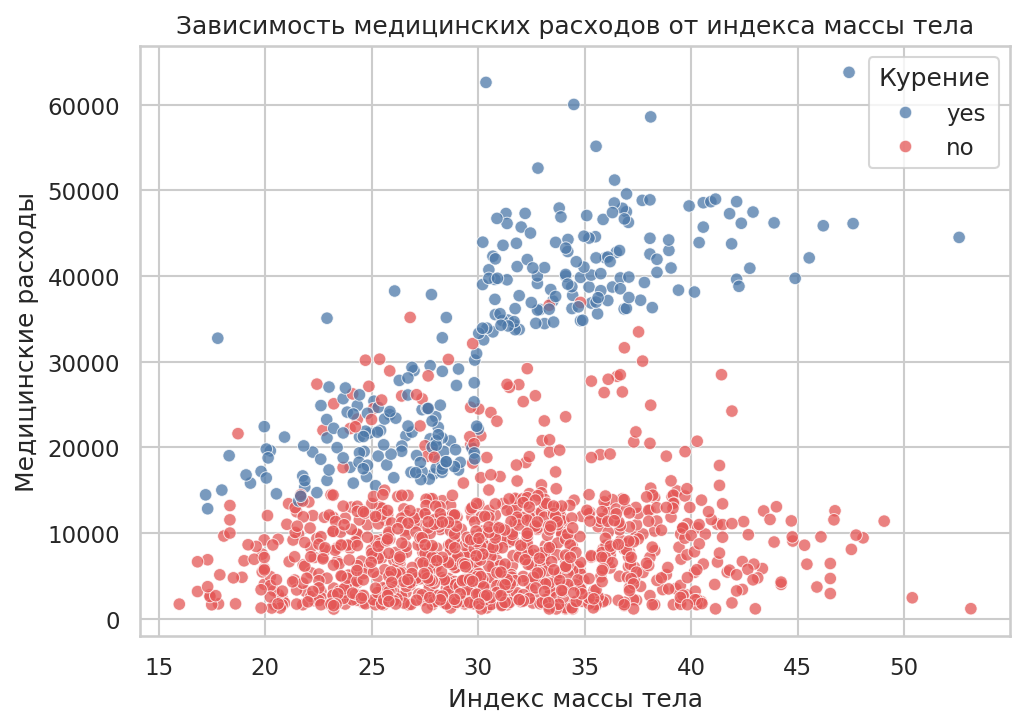

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=raw, x="bmi", y="charges", hue="smoker", palette=["#4C78A8", "#E45756"], alpha=0.75, ax=ax)
ax.set_xlabel(LABELS["bmi"])
ax.set_ylabel(LABELS["charges"])
ax.set_title("Зависимость медицинских расходов от индекса массы тела")
ax.legend(title="Курение")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_target_vs_bmi_smoker.png", bbox_inches="tight")
plt.show()


### Пояснение к зависимости расходов от индекса массы тела

- **Направление связи:** с ростом BMI расходы в среднем увеличиваются, но облако точек широкое: одного индекса массы тела недостаточно для точного прогноза.
- **Роль курения:** при одинаковом BMI курящие пациенты образуют верхнюю группу. Средние расходы курящих равны **32 050,23**, некурящих — **8 434,27**.
- **Край распределения:** самые большие счета плохо укладываются в одну прямую. Линейная модель будет сглаживать эти дорогие случаи.


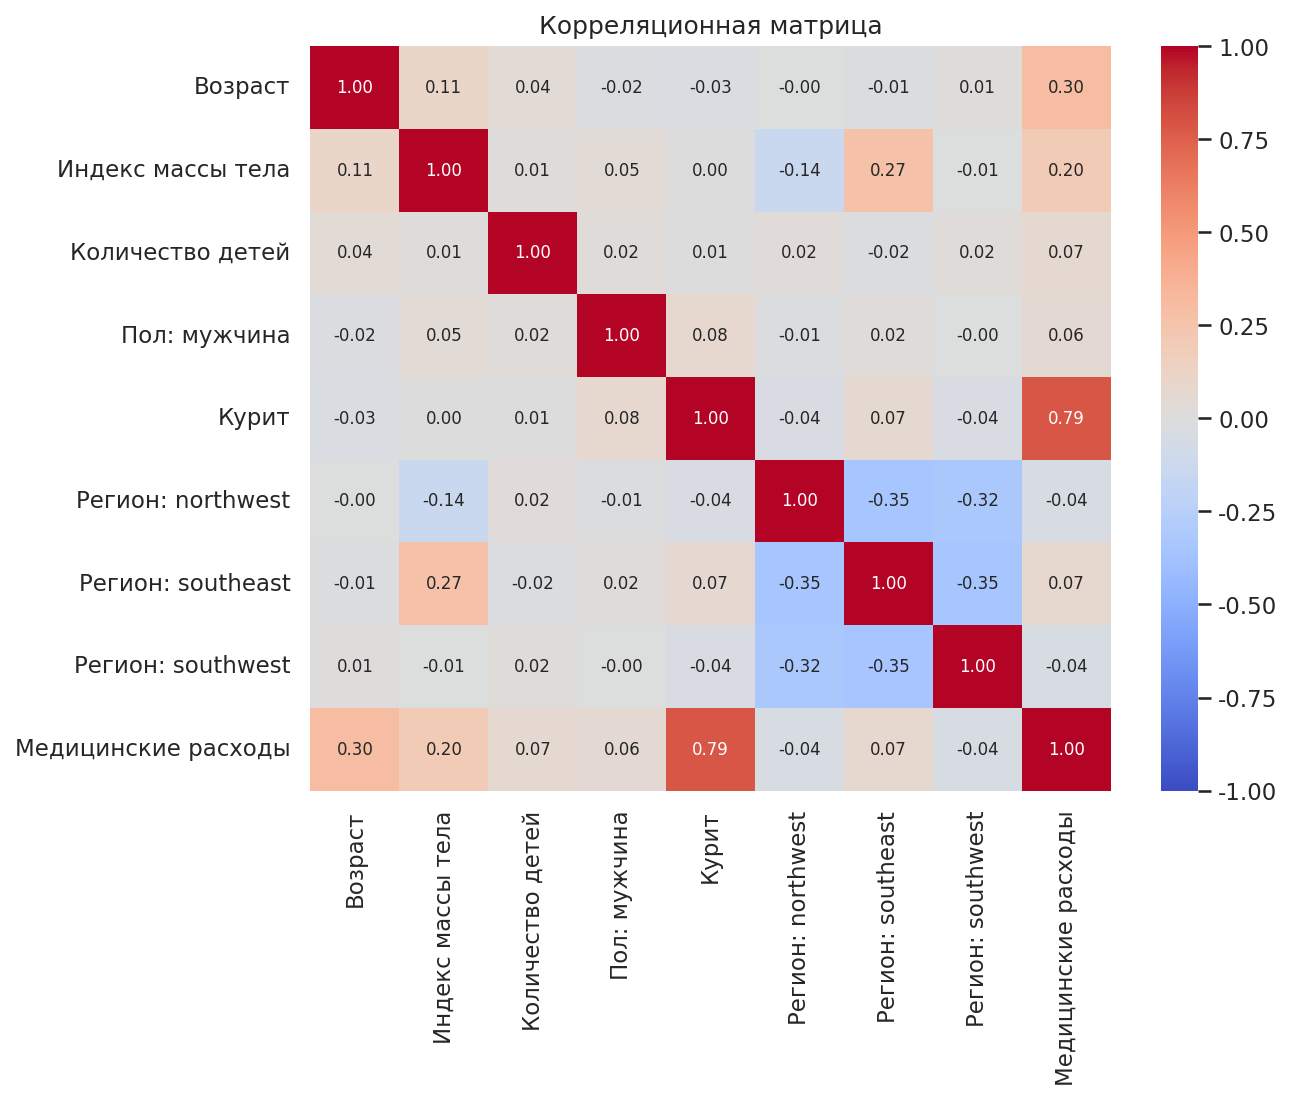

,корреляция с расходами
Регион: southwest,-0.043
Регион: northwest,-0.040
Пол: мужчина,0.057
Количество детей,0.068
Регион: southeast,0.074
Индекс массы тела,0.198
Возраст,0.299
Курит,0.787


In [6]:
corr = data[FEATURES + [TARGET]].corr()
corr.rename(index=LABELS, columns=LABELS).to_csv(OUTPUT_DIR / "correlation.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr.rename(index=LABELS, columns=LABELS),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Корреляционная матрица")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_correlation.png", bbox_inches="tight")
plt.show()

display(
    corr[TARGET]
    .drop(TARGET)
    .sort_values()
    .rename(index=LABELS)
    .round(3)
    .to_frame("корреляция с расходами")
)


### Пояснение к матрице корреляций

- **Связь с целевой переменной:**
  - сильнее всего с расходами связано курение ($r = 0{,}79$);
  - возраст связан положительно ($r = 0{,}30$), индекс массы тела — слабее ($r = 0{,}20$);
  - пол, число детей и регион имеют корреляции по модулю меньше 0,08.
- **Связь предикторов между собой:** парные корреляции признаков невелики. В отличие от набора, где несколько технических характеристик описывают один и тот же фактор, здесь признаки несут в основном разную информацию. Это уже говорит о слабой мультиколлинеарности, но окончательно её проверяет VIF.


,label,VIF
6,Регион: southeast,1.65
7,Регион: southwest,1.53
5,Регион: northwest,1.52
1,Индекс массы тела,1.11
0,Возраст,1.02
4,Курит,1.01
3,Пол: мужчина,1.01
2,Количество детей,1.00


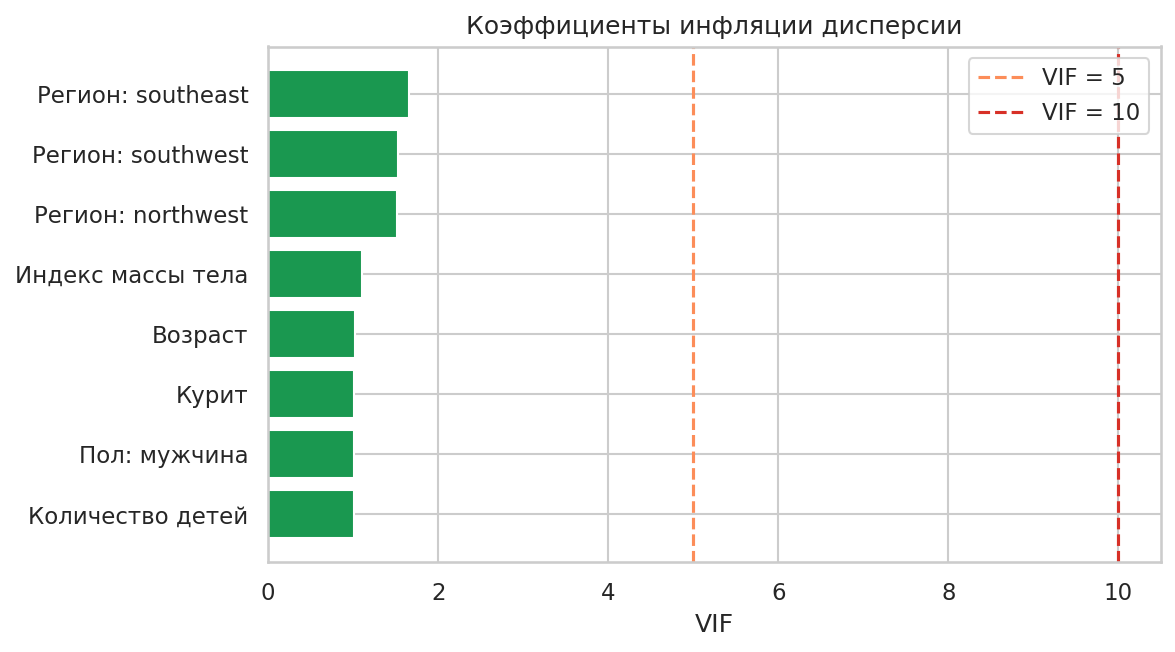

In [7]:
matrix = add_constant(data[FEATURES].astype(float))
vif_rows = []
for index, name in enumerate(matrix.columns):
    if name == "const":
        continue
    vif_rows.append(
        {
            "feature": name,
            "label": LABELS[name],
            "VIF": variance_inflation_factor(matrix.values, index),
        }
    )

vif = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif.to_csv(OUTPUT_DIR / "vif_before.csv", index=False, encoding="utf-8-sig")
display(vif[["label", "VIF"]].round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#d73027" if value >= 10 else "#fc8d59" if value >= 5 else "#1a9850" for value in vif["VIF"]]
ax.barh(vif["label"], vif["VIF"], color=colors)
ax.axvline(5, color="#fc8d59", linestyle="--", label="VIF = 5")
ax.axvline(10, color="#d73027", linestyle="--", label="VIF = 10")
ax.set_xlabel("VIF")
ax.set_title("Коэффициенты инфляции дисперсии")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_vif.png", bbox_inches="tight")
plt.show()


### Пояснение к коэффициентам VIF

- **Определение.** Фактор инфляции дисперсии признака $i$ равен
$$VIF_i = \frac{1}{1 - R_i^2},$$
где $R_i^2$ — коэффициент детерминации регрессии этого признака на все остальные. В матрицу добавлен столбец единиц, потому что у моделей есть свободный член.
- **Пороги:** $VIF < 5$ — мультиколлинеарности нет, $5 \le VIF \le 10$ — умеренная, $VIF > 10$ — сильная.
- **Результат:** максимальный VIF равен **1,65** у признака «Регион: southeast». Все восемь признаков лежат ниже порога 5.
- **Следствие:** коэффициенты исходной регрессии можно интерпретировать по отдельности. PCA всё равно применяется по заданию: он даст ортогональные компоненты и позволит сравнить качество прогноза.


In [8]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


MAPE_SCORER = make_scorer(mean_absolute_percentage_error, greater_is_better=False)
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
    "mape": MAPE_SCORER,
}


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }


def make_pipeline(model, n_components=None):
    steps = [("scaler", StandardScaler())]
    if n_components is not None:
        steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)


def train_models(x_train, y_train, x_test, y_test, feature_set, n_components=None):
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    alphas = np.logspace(-3, 3, 50)
    rows = []
    predictions = {}
    fitted = {}

    linear = make_pipeline(LinearRegression(), n_components)
    cv_result = cross_validate(linear, x_train, y_train, cv=cv, scoring=SCORING)
    linear.fit(x_train, y_train)
    prediction = linear.predict(x_test)
    rows.append(
        {
            "model": "linear",
            "model_title": MODEL_TITLES["linear"],
            "alpha": np.nan,
            "CV_RMSE": float(-cv_result["test_rmse"].mean()),
            "CV_R2": float(cv_result["test_r2"].mean()),
            "CV_MAPE": float(-cv_result["test_mape"].mean()),
            **regression_metrics(y_test, prediction),
        }
    )
    predictions["linear"] = prediction
    fitted["linear"] = linear

    for name, model in (("ridge", Ridge(max_iter=10000)), ("lasso", Lasso(max_iter=50000))):
        search = GridSearchCV(
            make_pipeline(model, n_components),
            param_grid={"model__alpha": alphas},
            scoring=SCORING,
            refit="rmse",
            cv=cv,
        )
        search.fit(x_train, y_train)
        best_index = int(search.best_index_)
        prediction = search.predict(x_test)
        rows.append(
            {
                "model": name,
                "model_title": MODEL_TITLES[name],
                "alpha": float(search.best_params_["model__alpha"]),
                "CV_RMSE": float(-search.cv_results_["mean_test_rmse"][best_index]),
                "CV_R2": float(search.cv_results_["mean_test_r2"][best_index]),
                "CV_MAPE": float(-search.cv_results_["mean_test_mape"][best_index]),
                **regression_metrics(y_test, prediction),
            }
        )
        predictions[name] = prediction
        fitted[name] = search.best_estimator_

    result = pd.DataFrame(rows)
    result.insert(0, "feature_set", feature_set)
    result.insert(1, "features_title", FEATURE_SET_TITLES[feature_set])
    return result, predictions, fitted


def coefficients_table(fitted, feature_names):
    rows = []
    for name, estimator in fitted.items():
        model = estimator.named_steps["model"]
        if "pca" in estimator.named_steps:
            names = [f"PC{i}" for i in range(1, estimator.named_steps["pca"].n_components_ + 1)]
        else:
            names = feature_names
        for feature, value in zip(names, model.coef_):
            rows.append({"model": MODEL_TITLES[name], "feature": feature, "coefficient": value})
        rows.append({"model": MODEL_TITLES[name], "feature": "intercept", "coefficient": model.intercept_})
    return pd.DataFrame(rows)


In [9]:
x = data[FEATURES]
y = data[TARGET]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

before, pred_before, fitted_before = train_models(
    x_train, y_train, x_test, y_test, "original"
)
display(before[["model_title", "alpha", "CV_RMSE", "CV_R2", "CV_MAPE", "RMSE", "R2", "MAPE"]].round(3))


,model_title,alpha,CV_RMSE,CV_R2,CV_MAPE,RMSE,R2,MAPE
0,Линейная,NaN,6123.354,0.739,42.410,5796.285,0.784,46.888
1,Гребневая,2.024,6123.293,0.739,42.483,5797.708,0.783,46.974
2,Лассо,104.811,6118.764,0.739,42.326,5837.964,0.780,48.197


### Пояснение к моделям на исходных признаках

- **Схема проверки:** выборка разделена в отношении **80/20** — **1070** наблюдений на обучение и **268** на тест (`random_state = 42`). Коэффициент штрафа Ridge и Lasso выбран 5-фолдовой кросс-валидацией только по обучающей части. Стандартизация стоит внутри конвейера, поэтому на каждом фолде $\mu$ и $\sigma$ считаются по обучающей части фолда.
- **Качество на тесте:**
  - линейная регрессия: $RMSE = 5796{,}28$, $R^2 = 0{,}784$, $MAPE = 46{,}89\%$;
  - гребневая регрессия ($\alpha = 2{,}024$): $RMSE = 5797{,}71$, $R^2 = 0{,}783$, $MAPE = 46{,}97\%$;
  - лассо ($\alpha = 104{,}811$): $RMSE = 5837{,}96$, $R^2 = 0{,}780$, $MAPE = 48{,}20\%$.
- **Сравнение моделей:** три модели близки. Лучший тестовый RMSE у линейной регрессии. Кросс-валидация даёт $RMSE \approx 6123$ и $R^2 \approx 0{,}74$. MAPE около 47% велик из-за правостороннего хвоста расходов: абсолютная ошибка в несколько тысяч на небольших счетах даёт большой процент. По $R^2$ модель объясняет около 78,4% дисперсии расходов.


In [10]:
coefficients = coefficients_table(fitted_before, [LABELS[name] for name in FEATURES])
coefficients.to_csv(OUTPUT_DIR / "coefficients_original.csv", index=False, encoding="utf-8-sig")
display(coefficients.pivot(index="feature", columns="model", values="coefficient").round(3))


model,Гребневая,Лассо,Линейная
feature,,,
intercept,13346.090,13346.090,13346.090
Возраст,3607.656,3524.730,3614.975
Индекс массы тела,2032.457,1886.053,2036.228
Количество детей,516.630,420.706,516.890
Курит,9539.873,9447.874,9558.481
Пол: мужчина,-7.926,0.000,-9.293
Регион: northwest,-157.119,0.000,-158.141
Регион: southeast,-286.905,-6.283,-290.157
Регион: southwest,-347.416,-96.400,-349.111


### Пояснение к коэффициентам стандартизованных моделей

- **Как читать коэффициент:** признаки приведены к нулевому среднему и единичной дисперсии. Коэффициент показывает, на сколько денежных единиц меняется прогноз, если признак увеличивается на одно своё стандартное отклонение.
- **Согласованные знаки:** курение входит с коэффициентом **9 558**, возраст — с коэффициентом **3 615**, индекс массы тела — с коэффициентом **2 036**. Знаки совпадают с корреляциями: эти факторы повышают расходы.
- **Слабые признаки:** пол и региональные индикаторы имеют небольшие коэффициенты. Лассо уменьшает часть из них почти до нуля, потому что их вклад в прогноз мал.
- **Мультиколлинеарность здесь не меняет знаки.** VIF всех признаков ниже 5, поэтому противоречия между корреляцией и коэффициентом, характерного для сильно связанных признаков, нет. Регуляризация почти не улучшает RMSE.


In [11]:
scaler = StandardScaler()
scaled_train = scaler.fit_transform(x_train)
pca_full = PCA(random_state=RANDOM_STATE).fit(scaled_train)

ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratio)
eigenvalues = pca_full.explained_variance_
n_components = int(np.searchsorted(cumulative, VARIANCE_THRESHOLD) + 1)
n_components = min(n_components, len(ratio))
n_kaiser = int(np.sum(eigenvalues > 1))
explained = float(cumulative[n_components - 1])

component_table = pd.DataFrame(
    {
        "component": np.arange(1, len(ratio) + 1),
        "eigenvalue": eigenvalues,
        "explained_variance_ratio": ratio,
        "cumulative_variance_ratio": cumulative,
    }
)
component_table.to_csv(OUTPUT_DIR / "pca_variance.csv", index=False, encoding="utf-8-sig")
display(component_table.round(4))


,component,eigenvalue,explained_variance_ratio,cumulative_variance_ratio
0,1,1.4931,0.1865,0.1865
1,2,1.3325,0.1664,0.3529
2,3,1.1249,0.1405,0.4934
3,4,1.0679,0.1334,0.6267
4,5,0.9658,0.1206,0.7473
5,6,0.9028,0.1127,0.8601
6,7,0.7994,0.0998,0.9599
7,8,0.3211,0.0401,1.0000


### Пояснение к выбору числа главных компонент

- **Как строилось разложение:** признаки стандартизованы, компоненты найдены только по обучающей выборке. Тестовые пациенты не участвуют в выборе осей.
- **Спектр дисперсии:** первая компонента объясняет **18,6%** дисперсии признаков ($\lambda_1 = 1{,}49$), вторая — ещё **16,6%**. Собственные значения убывают плавно: признаки слабо связаны, поэтому дисперсия не концентрируется в одной компоненте.
- **Два правила отбора:**
  - по критерию Кайзера ($\lambda \ge 1$) остаются **4** компоненты;
  - по правилу накопленной дисперсии не ниже 95% остаются **7** компонент, они объясняют **96,0%**.
- **Почему взято правило 95%:** критерий Кайзера отбрасывает компоненты, в которых ещё есть возраст, курение и число детей. Для прогноза расходов эти факторы нужны, поэтому в модели оставляются 7 компонент.


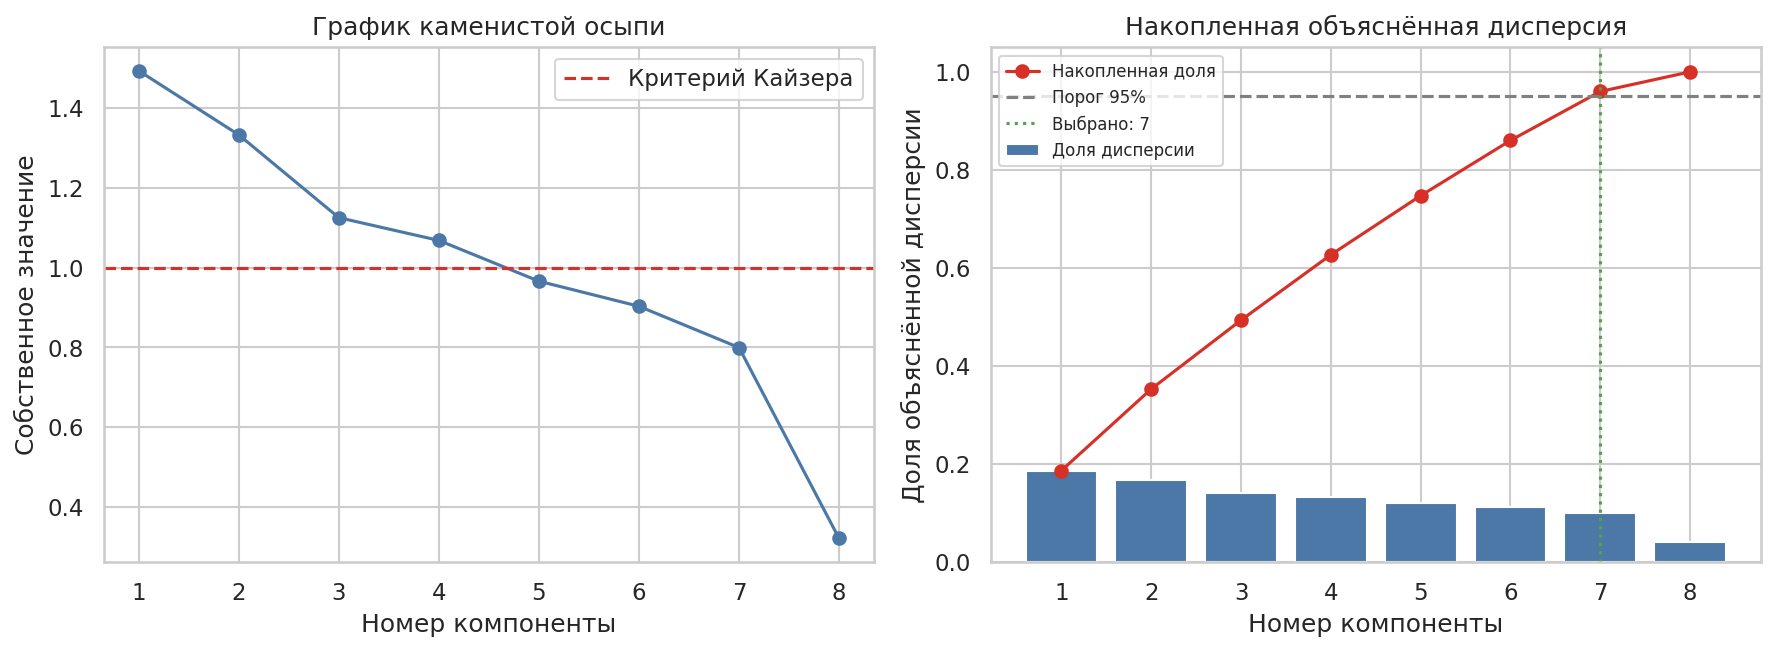

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
numbers = np.arange(1, len(ratio) + 1)

axes[0].plot(numbers, eigenvalues, marker="o", color="#4C78A8")
axes[0].axhline(1, color="#d73027", linestyle="--", label="Критерий Кайзера")
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].set_title("График каменистой осыпи")
axes[0].set_xticks(numbers)
axes[0].legend()

axes[1].bar(numbers, ratio, color="#4C78A8", label="Доля дисперсии")
axes[1].plot(numbers, cumulative, color="#d73027", marker="o", label="Накопленная доля")
axes[1].axhline(VARIANCE_THRESHOLD, color="gray", linestyle="--", label="Порог 95%")
axes[1].axvline(n_components, color="#54A24B", linestyle=":", label=f"Выбрано: {n_components}")
axes[1].set_xlabel("Номер компоненты")
axes[1].set_ylabel("Доля объяснённой дисперсии")
axes[1].set_title("Накопленная объяснённая дисперсия")
axes[1].set_xticks(numbers)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_scree.png", bbox_inches="tight")
plt.show()


### Пояснение к графику каменистой осыпи

- **Излом:** собственного крутого обрыва после одной-двух компонент нет. Значения снижаются постепенно, что согласуется со слабой мультиколлинеарностью.
- **Порог 95%:** накопленная доля дисперсии пересекает горизонталь 0,95 на 7-й компоненте. Вертикальная отметка на правом графике фиксирует этот выбор.
- **Решение для моделей:** в регрессию входят 7 главных компонент. Сжатие небольшое: из 8 признаков остаются 7.


In [13]:
loadings = pd.DataFrame(
    pca_full.components_[:n_components].T,
    index=[LABELS[name] for name in FEATURES],
    columns=[f"PC{i}" for i in range(1, n_components + 1)],
)
loadings.to_csv(OUTPUT_DIR / "pca_loadings.csv", encoding="utf-8-sig")
display(loadings.round(3))


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Возраст,0.053,0.074,0.711,0.199,-0.200,0.377,-0.514
Индекс массы тела,0.474,0.061,0.347,0.104,-0.247,0.095,0.742
Количество детей,-0.063,-0.038,0.328,0.484,0.732,-0.325,0.107
Пол: мужчина,0.003,-0.077,-0.176,0.658,-0.547,-0.463,-0.126
Курит,0.105,-0.097,-0.438,0.513,0.168,0.703,0.041
Регион: northwest,-0.490,-0.545,0.194,0.008,-0.148,0.126,0.303
Регион: southeast,0.700,-0.233,-0.065,-0.092,0.116,-0.130,-0.215
Регион: southwest,-0.163,0.789,-0.033,0.102,-0.028,0.031,0.135


### Пояснение к факторным нагрузкам

- **ГК 1 (18,6% дисперсии).** Наибольшие по модулю нагрузки: Регион: southeast (+0.70), Регион: northwest (-0.49), Индекс массы тела (+0.47). Компонента в основном противопоставляет юго-восточный регион и высокий BMI северо-западному региону.
- **ГК 2 (16,6% дисперсии).** Наибольшие нагрузки: Регион: southwest (+0.79), Регион: northwest (-0.55), Регион: southeast (-0.23). Это региональный контраст southwest и northwest.
- **ГК 3 (14,0% дисперсии).** Наибольшие нагрузки: Возраст (+0.71), Курит (-0.44), Индекс массы тела (+0.35). Здесь выделяются возраст, курение и BMI.
- Остальные компоненты дробят пол, число детей и оставшуюся региональную информацию. Отдельного доминирующего фактора, который собрал бы большую часть дисперсии, в этих данных нет.


In [14]:
train_components = pca_full.transform(scaled_train)[:, :n_components]
component_frame = pd.DataFrame(train_components, columns=[f"PC{i}" for i in range(1, n_components + 1)])
component_matrix = add_constant(component_frame)
vif_pca_rows = []
for index, name in enumerate(component_matrix.columns):
    if name == "const":
        continue
    vif_pca_rows.append({"feature": name, "VIF": variance_inflation_factor(component_matrix.values, index)})
vif_pca = pd.DataFrame(vif_pca_rows)
vif_pca.to_csv(OUTPUT_DIR / "vif_after_pca.csv", index=False, encoding="utf-8-sig")
display(vif_pca.round(3))


,feature,VIF
0,PC1,1.0
1,PC2,1.0
2,PC3,1.0
3,PC4,1.0
4,PC5,1.0
5,PC6,1.0
6,PC7,1.0


### Пояснение к VIF после PCA

- У 7 отобранных компонент $VIF = 1{,}000$. Главные компоненты ортогональны, поэтому
$$Cov(ГК_i, ГК_j) = 0 \quad (i \ne j),$$
и линейная зависимость между новыми признаками устранена.
- Число признаков сократилось с **8 до 7**. При этом сохранено **96,0%** дисперсии исходных признаков. Поскольку исходные VIF и так были близки к 1, выигрыш PCA здесь в основном формальный.


In [15]:
after, pred_after, fitted_after = train_models(
    x_train, y_train, x_test, y_test, "pca", n_components=n_components
)
display(after[["model_title", "alpha", "CV_RMSE", "CV_R2", "CV_MAPE", "RMSE", "R2", "MAPE"]].round(3))

pca_coefficients = coefficients_table(fitted_after, None)
pca_coefficients.to_csv(OUTPUT_DIR / "coefficients_pca.csv", index=False, encoding="utf-8-sig")

metrics = pd.concat([before, after], ignore_index=True)
metrics.to_csv(OUTPUT_DIR / "metrics.csv", index=False, encoding="utf-8-sig")
display(
    metrics[["features_title", "model_title", "alpha", "CV_RMSE", "CV_R2", "CV_MAPE", "RMSE", "R2", "MAPE"]].round(3)
)


,model_title,alpha,CV_RMSE,CV_R2,CV_MAPE,RMSE,R2,MAPE
0,Линейная,NaN,6128.793,0.738,42.378,5830.998,0.781,47.997
1,Гребневая,0.869,6128.784,0.738,42.404,5831.543,0.781,48.037
2,Лассо,19.307,6128.560,0.739,42.366,5833.408,0.781,47.946


,features_title,model_title,alpha,CV_RMSE,CV_R2,CV_MAPE,RMSE,R2,MAPE
0,Исходные признаки,Линейная,NaN,6123.354,0.739,42.410,5796.285,0.784,46.888
1,Исходные признаки,Гребневая,2.024,6123.293,0.739,42.483,5797.708,0.783,46.974
2,Исходные признаки,Лассо,104.811,6118.764,0.739,42.326,5837.964,0.780,48.197
3,Главные компоненты,Линейная,NaN,6128.793,0.738,42.378,5830.998,0.781,47.997
4,Главные компоненты,Гребневая,0.869,6128.784,0.738,42.404,5831.543,0.781,48.037
5,Главные компоненты,Лассо,19.307,6128.560,0.739,42.366,5833.408,0.781,47.946


### Пояснение к моделям на главных компонентах

- **Качество на тесте:** лучшая модель — линейная регрессия: $RMSE = 5831{,}00$, $R^2 = 0{,}781$, $MAPE = 48{,}00\%$.
- **Сравнение с исходными признаками:** у линейной модели RMSE изменился с **5 796,28** до **5 831,00**, то есть на **0,60%**, а $R^2$ — с 0,784 до 0,781.
- **Почему точность почти не выросла:** PCA сохраняет дисперсию признаков и не настроен на целевую переменную. При слабой мультиколлинеарности замена 8 признаков на 7 компонент не добавляет новой информации о расходах. Разница между линейной, гребневой и лассо-регрессией по-прежнему мала.


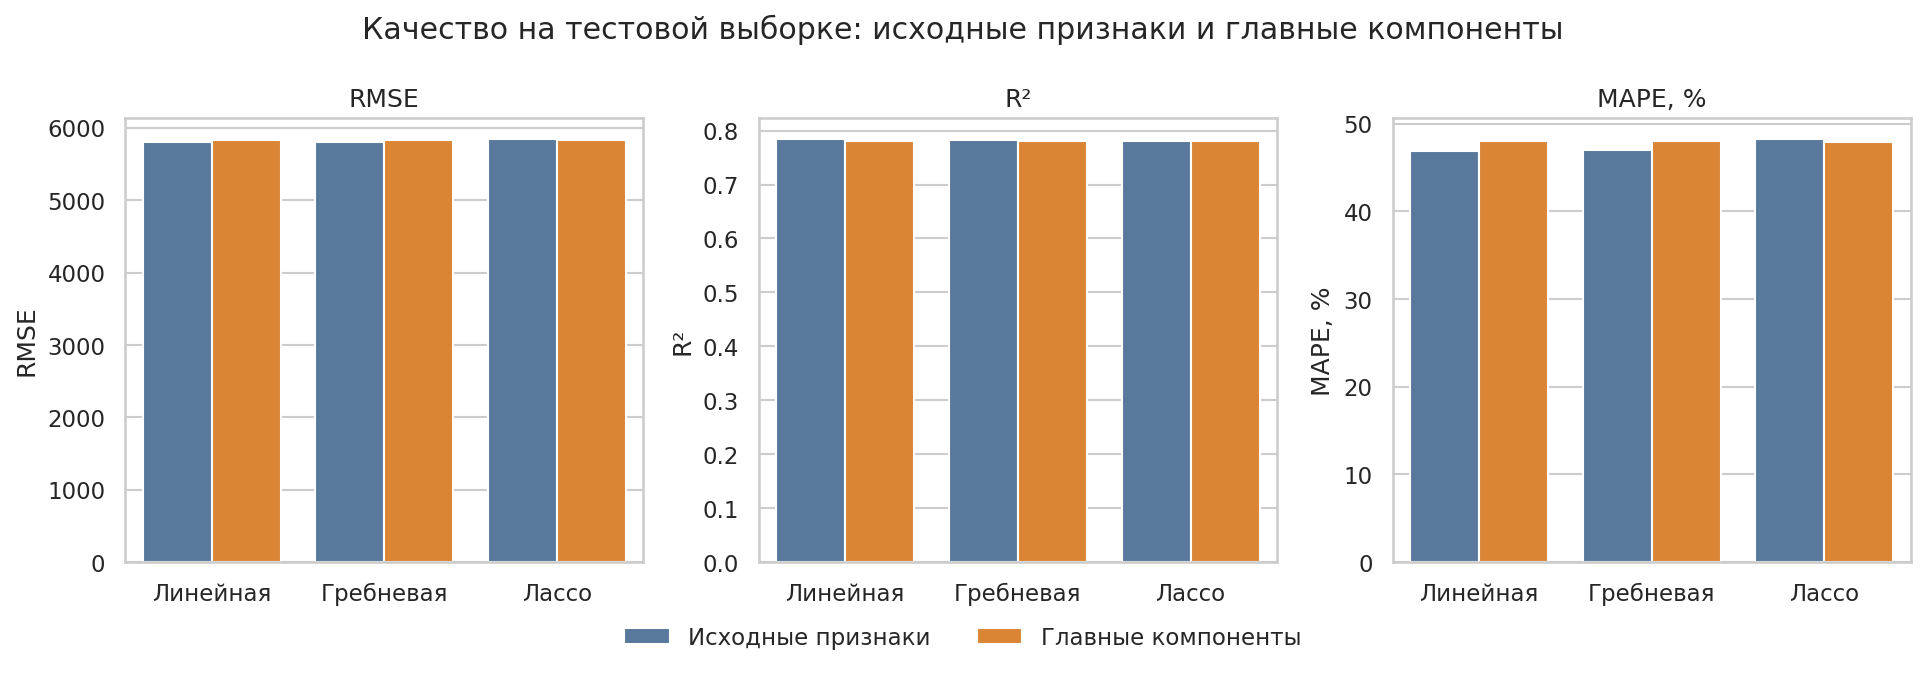

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
order = [MODEL_TITLES[name] for name in ("linear", "ridge", "lasso")]
for ax, metric, title in zip(axes, ("RMSE", "R2", "MAPE"), ("RMSE", "R²", "MAPE, %")):
    sns.barplot(
        data=metrics,
        x="model_title",
        y=metric,
        hue="features_title",
        order=order,
        hue_order=["Исходные признаки", "Главные компоненты"],
        ax=ax,
        palette=["#4C78A8", "#F58518"],
    )
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.set_title(title)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Качество на тестовой выборке: исходные признаки и главные компоненты")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_metrics.png", bbox_inches="tight")
plt.show()


### Пояснение к диаграмме сравнения метрик

- Модели на исходных признаках и модели на главных компонентах дают почти одинаковые RMSE, $R^2$ и MAPE.
- Внутри каждой группы три столбца близки по высоте. Линейная регрессия, Ridge и Lasso предсказывают расходы практически одинаково.
- Сжатие пространства формально устраняет зависимость признаков, но на этих данных почти не меняет ошибку прогноза.


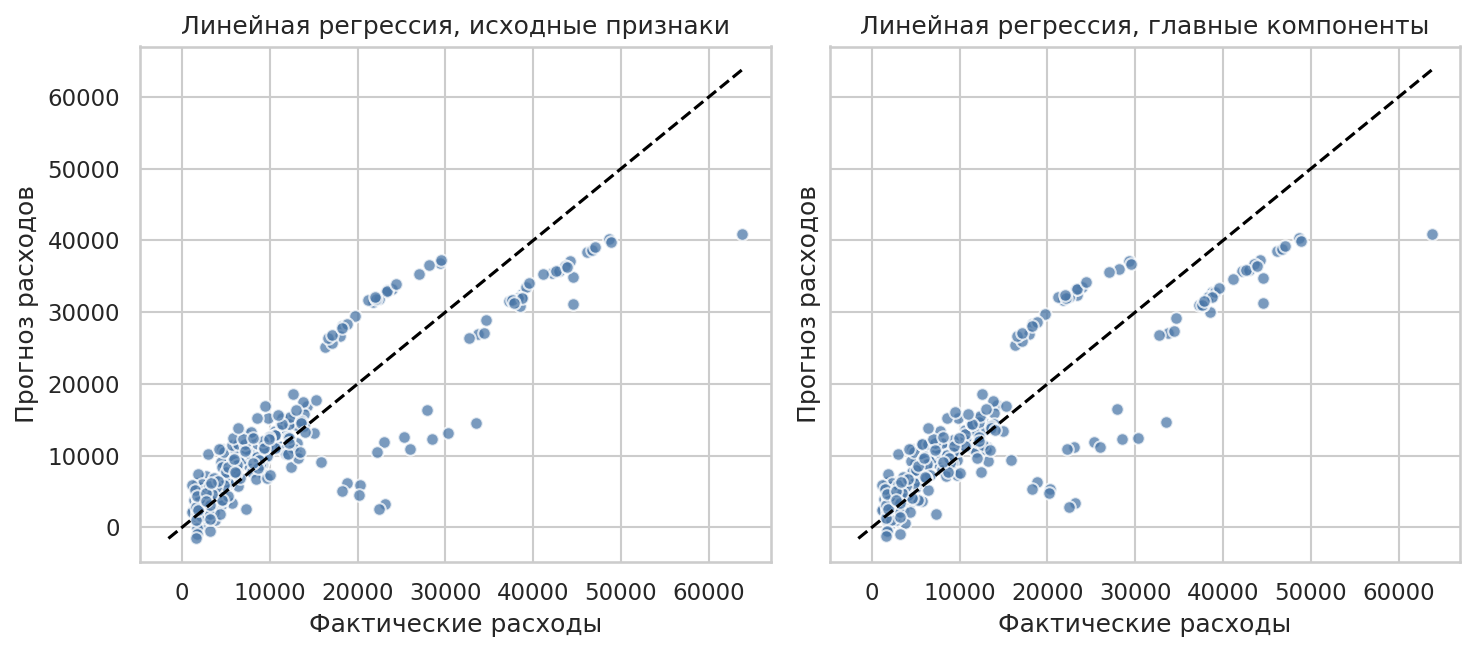

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
pairs = (
    (axes[0], pred_before["linear"], "Линейная регрессия, исходные признаки"),
    (axes[1], pred_after["linear"], "Линейная регрессия, главные компоненты"),
)
forecast = np.concatenate([pred_before["linear"], pred_after["linear"], np.asarray(y_test)])
low, high = float(forecast.min()), float(forecast.max())
for ax, prediction, title in pairs:
    ax.scatter(y_test, prediction, alpha=0.75, color="#4C78A8", edgecolor="white")
    ax.plot([low, high], [low, high], linestyle="--", color="black")
    ax.set_title(title)
    ax.set_xlabel("Фактические расходы")
    ax.set_ylabel("Прогноз расходов")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_pred_vs_actual.png", bbox_inches="tight")
plt.show()


### Пояснение к графикам «факт — прогноз»

- Точки вытянуты вдоль диагонали $y = x$: в среднем прогноз следует за фактическими расходами и на исходных признаках, и на главных компонентах.
- Заметное отклонение есть у дорогих случаев. Например, фактические расходы **63 770** линейная модель на исходных признаках оценивает примерно в **40 920**.
- Линейная зависимость описывает основную массу пациентов и хуже — верхний хвост, где счета особенно велики. Переход к главным компонентам этот краевой промах не устраняет.


---
## Заключение

На датасете Medical Cost Personal Dataset решены поставленные задачи.

1. **Разведочный анализ.** В выборке 1338 пациентов, пропусков нет. Средние расходы равны 13 270,42, медиана — 9 382,03: распределение смещено вправо. Расходы резко выше у курящих пациентов.
2. **Предобработка.** Пол, курение и регион закодированы индикаторами с базовыми категориями «женщина», «не курит» и northeast. Выборка разделена 80/20 (1070 и 268), признаки стандартизованы внутри конвейера по обучающей части фолда.
3. **Мультиколлинеарность.** Сильной связи признаков нет: максимальный VIF равен **1,65**, все значения ниже 5. С расходами сильнее всего коррелирует курение ($r = 0{,}79$).
4. **Модели на исходных признаках.** Лучший тест у линейной регрессии: $RMSE = 5796{,}28$, $R^2 = 0{,}784$, $MAPE = 46{,}89\%$. Ridge и Lasso отличаются от неё незначительно. Регуляризация почти не повышает точность, потому что мультиколлинеарности нет.
5. **Факторный анализ.** По правилу 95% отобраны 7 главных компонент (96,0% дисперсии). Критерий Кайзера оставил бы 4. Первые компоненты разделяют регионы, BMI, возраст и курение. После PCA все VIF равны 1.
6. **Сравнение.** На компонентах лучший RMSE — **5 831,00** при $R^2 = 0{,}781$. Ошибка линейной модели изменилась на 0,60%. Для прогноза расходов достаточно линейной регрессии по исходным признакам. Главный фактор — курение. Линейная модель по-прежнему сглаживает самые дорогие случаи.

---
## Список использованных источников

1. Medical Cost Personal Dataset // Kaggle. URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
2. Файл `insurance.csv`: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
3. *Hastie T., Tibshirani R., Friedman J.* The Elements of Statistical Learning. 2nd ed. Springer, 2009.
4. *Джеймс Г., Уиттен Д., Хасти Т., Тибширани Р.* Введение в статистическое обучение с примерами на языке R. М.: ДМК Пресс, 2016.
5. *Jolliffe I. T.* Principal Component Analysis. 2nd ed. Springer, 2002.
6. Документация scikit-learn: https://scikit-learn.org/stable/modules/linear_model.html
7. Документация statsmodels (VIF): https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
